rough simulation of a qubit with dephase and amplitude demping using the master equation, 0 hamiltonian.

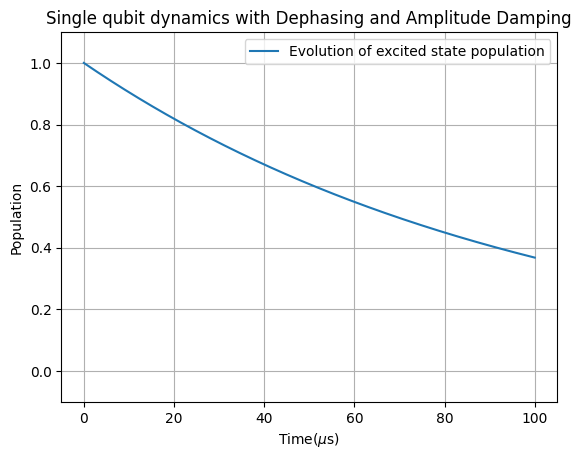

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


GroundState = np.array([[0, 0], [0, 1]])
ExcitedState = np.array([[1, 0], [0, 0]])

SigX = np.array([[0, 1], [1, 0]])
SigY = np.array([[0, -1j], [1j, 0]])
SigZ = np.array([[1, 0], [0, -1]])
SigM = np.array([[0, 0], [1, 0]])
SigP = np.array([[0, 1], [0, 0]])


GammaAmp = 1/100.0e-6
GammaPhase = 1/100.0e-6
p = 1.0
hbar = 1.0

L1Amp = (GammaAmp, SigM)
L1Phase = (GammaPhase, SigZ)


def vec(rho):
    return rho.flatten()
def unvec(rho_vec, dim):
    return rho_vec.reshape((dim, dim))
def commutator(H, rho):
    return H @ rho - rho @ H
def lindblad_rhs(t, rho_vec, H, Ls):
    dim = H.shape[0]
    rho = unvec(rho_vec, dim)
    drho = -1j * commutator(H, rho)
    for L in Ls:
        Gamma = L[0]
        Lind = L[1]
        LdagL = Lind.conj().T @ Lind
        drho += (Lind @ rho @ Lind.conj().T - 0.5 * (LdagL @ rho + rho @ LdagL)) * Gamma
    return vec(drho)


T = (0.0, 100.0e-6)
TSteps = 1000
TList = np.linspace(*T, TSteps)
H = np.zeros((2, 2), dtype=complex)
Ls = [L1Amp, L1Phase]
Rho0 = np.array([[1, 0], [0, 0]], dtype=complex)
Sol = solve_ivp(lindblad_rhs, T, vec(Rho0), t_eval=TList, args=(H, Ls))
PopExcited = [unvec(rho_vec, 2)[0, 0].real for rho_vec in Sol.y.T]


class SingleQubitSim():
    def __init__(self, 
                 H = np.zeros((2, 2), dtype=complex), 
                 Ls = [L1Amp, L1Phase], 
                 Rho0 = np.array([[1, 0], [0, 0]], dtype=complex),
                 T = None,
                 TSteps = None):
        
        self.TSteps = TSteps
        self.T = T
        self.TList = np.linspace(*self.T, self.TSteps)

        self.H = H
        self.Ls = Ls
        self.Rho0 = Rho0
        
        self.Sol = None
        self.PopExcited = None

    def run(self):
        Sol = solve_ivp(lindblad_rhs,
                        args=(self.H, self.Ls),
                        t_span=self.T,
                        y0=vec(self.Rho0),
                        t_eval=self.TList,
                        method='BDF', 
                        )
        PopExcited = [unvec(rho_vec, 2)[0, 0].real for rho_vec in Sol.y.T]
        self.Sol = Sol
        self.PopExcited = PopExcited
        return Sol, PopExcited


plt.figure()
plt.ylim(-0.1, 1.1)
plt.plot(Sol.t*1e6, PopExcited, label='Evolution of excited state population')
plt.xlabel('Time($\mu$s)')
plt.ylabel('Population')
plt.title('Single qubit dynamics with Dephasing and Amplitude Damping')
plt.legend()
plt.grid()
plt.show()

same as last box, hamiltonian being non-0

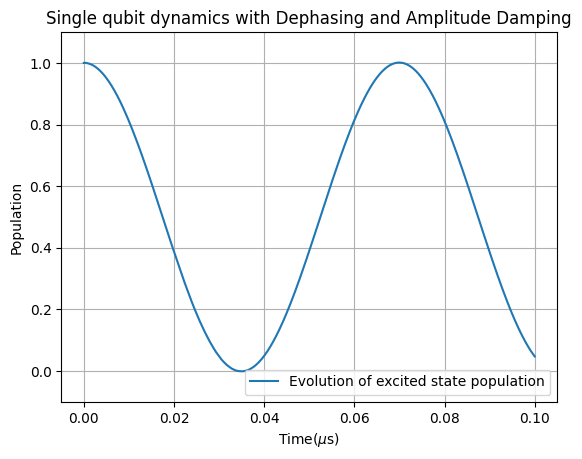

In [13]:
FreqQubit = 5.0e9
HamQubit = 2 * np.pi * FreqQubit * SigX
Transmon = SingleQubitSim(
    H = HamQubit, 
    Ls = [L1Amp, L1Phase], 
    Rho0 = np.array([[1, 0], [0, 0]], dtype=complex), 
    T=(0.0, 100.0e-9),
    TSteps=1000,
)
Transmon.run()

plt.figure()
plt.ylim(-0.1, 1.1)
plt.plot(Transmon.Sol.t*1e6, Transmon.PopExcited, label='Evolution of excited state population')
plt.xlabel('Time($\mu$s)')
plt.ylabel('Population')
plt.title('Single qubit dynamics with Dephasing and Amplitude Damping')
plt.legend()
plt.grid()
plt.show()

a simulation of transmon as a closed system

/var/folders/wg/k91xzcks6_7bqwz_43t5lnnr0000gn/T/ipykernel_10593/2415987705.py:31: RuntimeWarning: divide by zero encountered in matmul
  TransmonRhoT = U @ Rho0 @ U.conj().T
/var/folders/wg/k91xzcks6_7bqwz_43t5lnnr0000gn/T/ipykernel_10593/2415987705.py:31: RuntimeWarning: overflow encountered in matmul
  TransmonRhoT = U @ Rho0 @ U.conj().T
/var/folders/wg/k91xzcks6_7bqwz_43t5lnnr0000gn/T/ipykernel_10593/2415987705.py:31: RuntimeWarning: invalid value encountered in matmul
  TransmonRhoT = U @ Rho0 @ U.conj().T
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:323: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:323: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:323: RuntimeWarning: invalid v

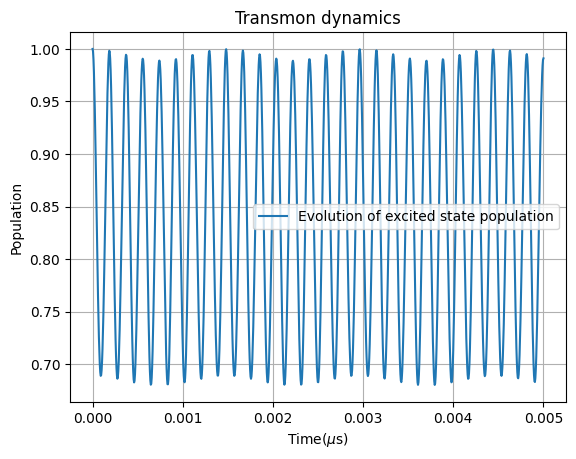

In [9]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

NMax = 20
Dim = NMax*2 + 1
NList = np.arange(-NMax, NMax+1)

NOp = np.diag(NList)
PhiOp = np.zeros((Dim, Dim), dtype=complex)
for i in range(Dim - 1):
    PhiOp[i, i+1] = 1
    PhiOp[i+1, i] = 1


EC = 0.2e9
EJ = 20.0e9

HTransmon = 4 * EC * (NOp @ NOp) - EJ * 0.5 * PhiOp

TList = np.linspace(0, 5e-9, 1000)

def TransmonRho0(NMax):
    Rho0 = np.zeros((Dim, Dim), dtype=complex)
    Rho0[0, 0] = 1
    return Rho0
Rho0 = TransmonRho0(Dim)
PopExcited = []
for t in TList:
    U = expm(-1j * HTransmon * t)
    TransmonRhoT = U @ Rho0 @ U.conj().T
    PopExcited.append(TransmonRhoT[0, 0].real)
plt.figure()
plt.plot(TList*1e6, PopExcited, label='Evolution of excited state population')
plt.xlabel('Time($\mu$s)')
plt.ylabel('Population')
plt.title('Transmon dynamics')
plt.legend()
plt.grid()
plt.show()


a simulation of transmon being a open system, using a hybrid redfield model

/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:323: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:323: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:323: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:355: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:355: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/runzhaoguo/miniconda3/envs/qc/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:355: RuntimeWarning: invalid value e

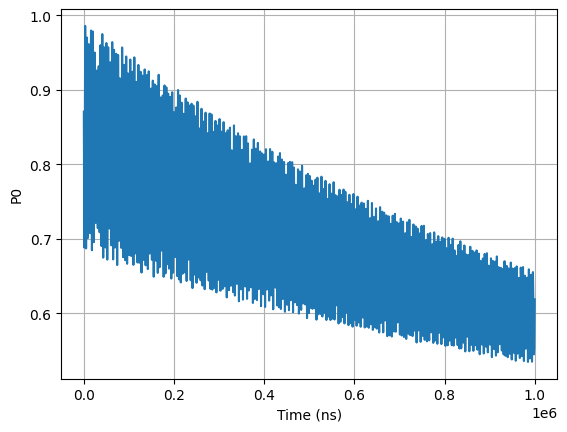

In [ ]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

NMax=20
Dim=2*NMax+1
NList=np.arange(-NMax,NMax+1)
NOp=np.diag(NList)
PhiOp=np.zeros((Dim,Dim),dtype=complex)
for i in range(Dim-1):
    PhiOp[i,i+1]=1
    PhiOp[i+1,i]=1
EC=0.2e9
EJ=20e9
H0=4*EC*(NOp@NOp)-0.5*EJ*PhiOp

Ax=NOp/np.linalg.norm(NOp)
Az=PhiOp/np.linalg.norm(PhiOp)
gx=5.7e6*2*np.pi
gz=4.4e6*2*np.pi
GammaX=1.0e5
GammaZ=5.0e4
b=6.0e5
K=10
GammaMin=1e4
GammaMax=5e7
gammas=np.logspace(np.log10(GammaMin),np.log10(GammaMax),K)
chis=np.ones(K)
dt=1e-6
TList=np.arange(0,1000e-6,dt)
Rho=np.zeros((Dim,Dim),dtype=complex)
Rho[0,0]=1
Pop=[]
for t in TList:
    for k in range(K):
        if np.random.rand()<gammas[k]*dt:
            chis[k]*=-1
    Hfluc=Az*b*np.sum(chis)
    H=H0+Hfluc
    U=expm(-1j*H*dt)
    Rho=U@Rho@U.conj().T
    Lx=-0.5*GammaX*(Ax@Ax@Rho-2*Ax@Rho@Ax+Rho@Ax@Ax)
    Lz=-0.5*GammaZ*(Az@Az@Rho-2*Az@Rho@Az+Rho@Az@Az)
    Rho=Rho+dt*(Lx+Lz)
    Pop.append(Rho[0,0].real)


plt.plot(TList*1e9,Pop)
plt.xlabel('Time (ns)')
plt.ylabel('P0')
plt.grid()
plt.show()
